Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       1.00      0.94      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.98      0.96        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.97      0.93      0.95        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



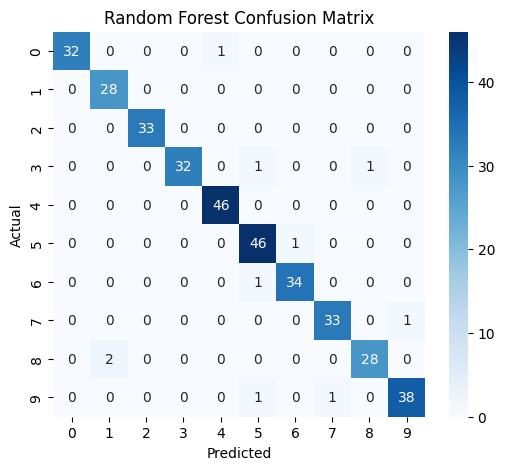

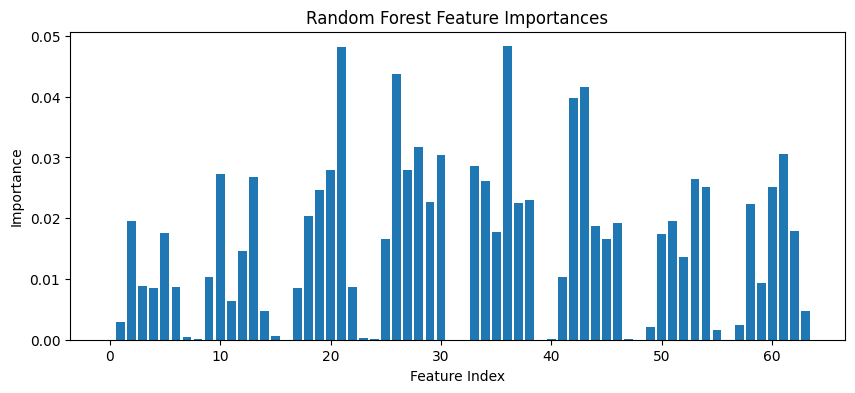

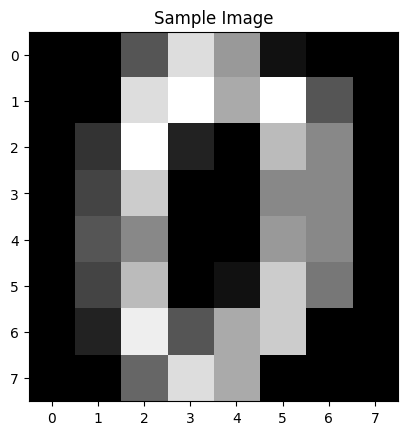

Predicted class: 0

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

Random Forest Accuracy: 0.9722222222222222
SVM Accuracy: 0.9861111111111112


In [1]:
# ---------------------------------------------------------
# 1. IMPORT LIBRARIES
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import seaborn as sns

# ---------------------------------------------------------
# 2. LOAD & PREPROCESS DATA
# ---------------------------------------------------------
digits = load_digits()

X = digits.images        # shape: (1797, 8, 8)
y = digits.target        # labels: 0–9

# Flatten images (Random Forest & SVM require 1D features)
X = X.reshape((X.shape[0], -1))

# Normalize pixel values (0–16 → 0–1)
X = X / 16.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 3. RANDOM FOREST + GRID SEARCH
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    rf, param_grid, cv=3, scoring="accuracy", n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Random Forest Parameters:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

# ---------------------------------------------------------
# 4. RANDOM FOREST EVALUATION
# ---------------------------------------------------------
y_pred_rf = best_rf.predict(X_test)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, cmap="Blues", fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------------------------------------
# 5. FEATURE IMPORTANCE VISUALIZATION
# ---------------------------------------------------------
importances = best_rf.feature_importances_
plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances)
plt.title("Random Forest Feature Importances")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

# ---------------------------------------------------------
# 6. PREDICT NEW IMAGE FUNCTION
# ---------------------------------------------------------
def predict_new_image(model, image):
    """
    image: 8x8 numpy array (like digits dataset)
    """
    img = image.reshape(1, -1) / 16.0
    prediction = model.predict(img)
    return prediction[0]

# Test prediction on a sample image
sample_img = digits.images[0]
plt.imshow(sample_img, cmap="gray")
plt.title("Sample Image")
plt.show()

print("Predicted class:", predict_new_image(best_rf, sample_img))

# ---------------------------------------------------------
# 7. BONUS: SVM CLASSIFIER
# ---------------------------------------------------------
svm_model = SVC(kernel="rbf", gamma="scale")
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Compare accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))